# 1 Module, Globals und Daten

## 1.1 Module


In [38]:
##### IMPORTS #####

import numpy as np
import pandas as pd

import xgboost as xgb
from xgboost import XGBClassifier

import sklearn.metrics as skm
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt

import os

## 1.2 Globals


In [39]:
##### Globals #####
dataPath = 'datasets/agmp/'                         # Set location of dataset


## 1.3 Daten


In [40]:
##### Data Import and Splitting #####
data = pd.read_csv(dataPath + 'gyro_mobile.csv')    # Dataset is imbalanced with only ~1.7% of all labels being 0's
data = data.drop(columns='timestamp')
xdata = data.iloc[:,:6]
ydata = data.iloc[:,6:]

xtrain_all, xvaltest, ytrain, yvaltest = train_test_split( 
    xdata,
    ydata,
    random_state=0,
    train_size=0.66,
    stratify=ydata                                  # Preserve label imbalance across train- and test datasets
)

xval_all, xtest_all, yval, ytest = train_test_split( 
    xvaltest,
    yvaltest,
    random_state=0,
    train_size=0.5,
    stratify=yvaltest                                  # Preserve label imbalance across train- and test datasets
)

## 1.4 Funktionen

In [41]:
def getFeatureImportances(model: XGBClassifier, prints: bool = False) -> list:
    
    # Erstellt eine Liste mit den relativen Wichtigkeiten aller Features des Modells nach durchschnittlichem Gain.

    featurenames  = [str(i) for i in list(model.feature_names_in_)]
    importances = [float(i) for i in list(model.feature_importances_)]

    namedimportances = list(zip(importances, featurenames))

    namedimportances = sorted(namedimportances, key=lambda x: x[0], reverse=True)

    if prints == True:
        i = 1
        for feature in namedimportances:
            print(f'{i}. {feature[1]}: \t{feature[0]}')
            i += 1

    return(namedimportances)

def getMostImportantFeatures(featureImportances, minGain: float = 0.95):
    
    # Gibt die ersten Elemente einer Liste entgegen, bis ein Wert minGain ueberschritten worden ist

    localRelWeights = []
    localFeatureNames = []
    weightsum = 0

    for feature in featureImportances:
        if (weightsum) < minGain:
            localRelWeights.append(feature[0])
            localFeatureNames.append(feature[1])
            
            weightsum += feature[0]

    return localFeatureNames, localRelWeights

def getBestDepth(listOfAccuracies, listOfSizes):  
        data = {'Accuracy': listOfAccuracies,
                'Size': listOfSizes}
        AccVsSize = pd.DataFrame(data)
        Suitable = AccVsSize[AccVsSize['Size']<1024]
        bestAccsWithinBoundaries = Suitable[Suitable['Accuracy']==max(Suitable['Accuracy'])]
        bestDepth = bestAccsWithinBoundaries[bestAccsWithinBoundaries['Size'] == min(bestAccsWithinBoundaries['Size'])]

        return bestDepth



## 1.5 Modellimport

In [42]:
# Parameters identical to clf_final in basemodell_gyro.ipynb

clf = XGBClassifier(objective = "binary:logistic",
                    tree_method = 'exact',
                    n_estimators = 1314,
                    max_depth = 1)
clf.load_model("model-exports/aktuelle-exports/base_agmp.json")

# 2 Feature Selection

## 2.1 Embedded: Feature Importance

### 2.1.1 Get (sorted) Feature Importances

In [43]:
ranking = getFeatureImportances(clf, False)
relWeights = []
featureNames = []

for feature in ranking:
    relWeights.append(feature[0])
    featureNames.append(feature[1])

### 2.1.2 Plot Feature Importances

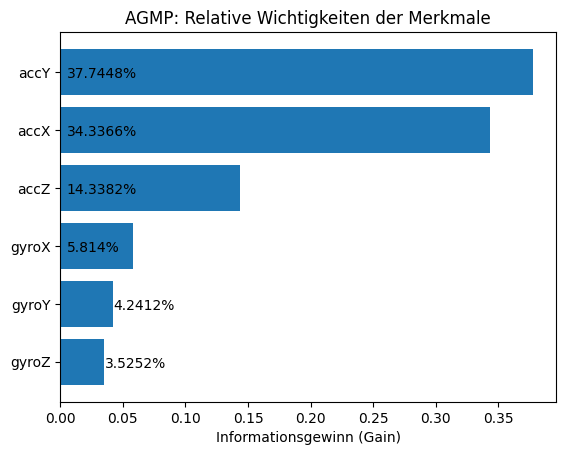

In [44]:
fig, ax = plt.subplots()

y_pos = np.arange(len(featureNames))

ax.barh(y_pos, relWeights, align='center')
ax.set_yticks(y_pos, labels=featureNames)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Informationsgewinn (Gain)')
ax.set_title('AGMP: Relative Wichtigkeiten der Merkmale')

index = 0
for i in relWeights:
    if i < 0.05:
        plt.text(i,index + 0.1,str(round(i*100,4))+"%")
        index +=1
    else:
        plt.text(0.005,index + 0.1,str(round(i*100,4))+"%")
        index +=1

plt.show()

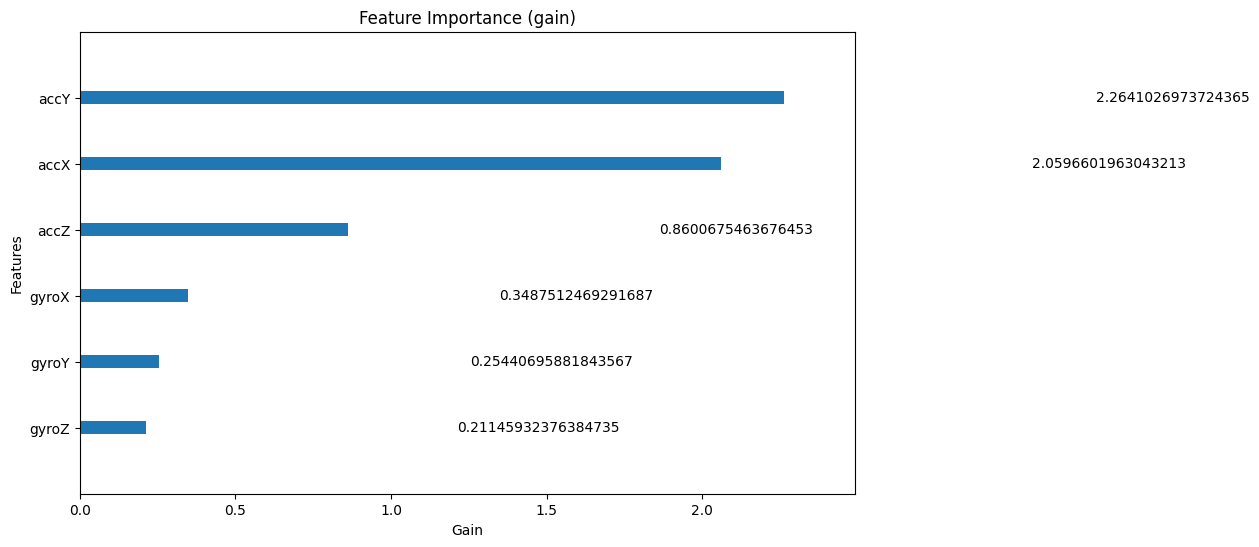

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

importance_type = 'gain'
xgb.plot_importance(clf, ax=ax, importance_type='gain',
                    max_num_features=6, grid=False, show_values=True)
plt.xlabel(f'{importance_type}'.capitalize())
plt.title(f'Feature Importance ({importance_type})')
plt.show()


### 2.1.3 Get most Important Features 

In [46]:
mINames, mIWeights = getMostImportantFeatures(ranking)
print(f"Gesamte Anzahl der Merkmale: {len(ranking)}")
print(f"Anzahl der Merkmale mit 95% Informationsgewinn: {len(mINames)}")

Gesamte Anzahl der Merkmale: 6
Anzahl der Merkmale mit 95% Informationsgewinn: 5


### 2.1.4 Teilmenge erstellen

In [47]:
xtrain = xtrain_all[mINames]
xval = xval_all[mINames]
xtest = xtest_all[mINames]

xtrain.to_csv("datasets/agmp/feature_selection/agmp_xtrain_emb.csv", index=False, sep=",")
xval.to_csv("datasets/agmp/feature_selection/agmp_xval_emb.csv",index=False, sep=",")
xtest.to_csv("datasets/agmp/feature_selection/agmp_xtest_emb.csv",index=False, sep=",")

ev_val = [(xval,yval)]
ev_all = [(xtrain,ytrain),(xval,yval),(xtest,ytest)]

### 2.1.5 Modell trainieren

In [48]:
classratio = len(data[data['Activity']==0]) / len(data[data['Activity']==1])

clf_fs = XGBClassifier(objective = "binary:logistic",
                       tree_method = 'exact',
                       scale_pos_weight = classratio,
                       n_estimators = 1314,
                       max_depth = 1
                       )

clf_fs.fit(xtrain,ytrain,
           eval_set=ev_val,
           verbose = 0
           )

yhat = clf_fs.predict(xtest)

print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') 

Balanced Accuracy-Score: 	0.8842386920223708


### 2.1.6 n_estimators und max_depth ermitteln

In [49]:
bestIterList = []
accListBalanced = []
jsonSizeList = []

maximum = 30

for i in range(1, maximum+1):

    clf_temp = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        scale_pos_weight = classratio,
        n_estimators = 100000,
        early_stopping_rounds = 10,
        max_depth = i
    )
    clf_temp.fit(
        xtrain, ytrain,
        eval_set = ev_val,
        verbose = 0
    )
    
    bestIter_temp = clf_temp.best_iteration

    clf_temp_bestIter = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        scale_pos_weight = classratio,
        n_estimators = bestIter_temp,
        max_depth = i
    )
    clf_temp_bestIter.fit(xtrain, ytrain)

    yhat_temp_bestIter = clf_temp_bestIter.predict(xtest)

    bAcc_temp = skm.balanced_accuracy_score(ytest, yhat_temp_bestIter)
    
    clf_temp_bestIter.save_model("clf_temp.json")

    jsonSizeList.append(os.path.getsize('clf_temp.json'))
    accListBalanced.append(bAcc_temp)
    bestIterList.append(bestIter_temp)

    os.remove('clf_temp.json')



In [50]:
jsonSizeList_KB = [x/1024 for x in jsonSizeList]
bestIterationValues = getBestDepth(accListBalanced, jsonSizeList_KB)
best_depth = bestIterationValues.index[0]+1

### 2.1.7 Graphen für Suche nach Params plotten

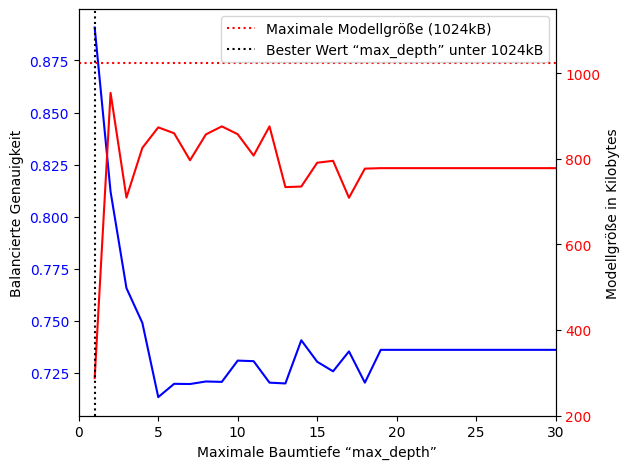

In [51]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Balancierte Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(1,31),accListBalanced[:30],color="blue")
ax.set_xlim(0,30)

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
twin.set_ylim(200,1150)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(1,31),jsonSizeList_KB[:30],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

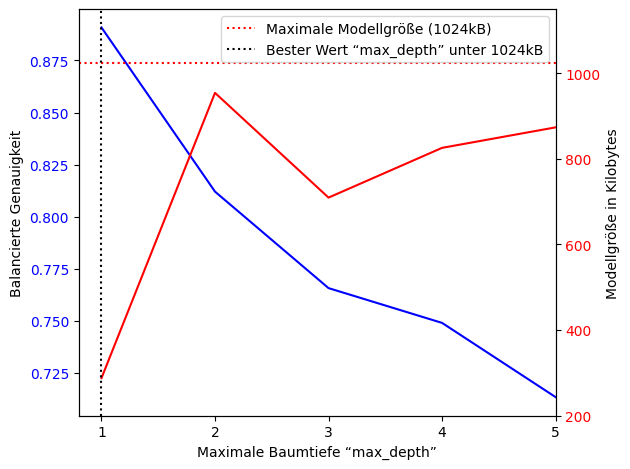

In [52]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Balancierte Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(1,6),accListBalanced[:5],color="blue")
ax.set_xticks([1,2,3,4,5])
ax.set_xlim((0.8),5)

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
twin.set_ylim(200,1150)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(1,6),jsonSizeList_KB[:5],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

### 2.1.8 Finales Modell erzeugen

In [53]:
clf_final = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    scale_pos_weight = classratio, # Increase weight of minority class 
    n_estimators = bestIterList[best_depth-1],
    max_depth = best_depth
)
clf_final.fit(
    xtrain,ytrain,
    eval_set = ev_all,
    verbose = 0
)

yhat_final = clf_final.predict(xtest)

clf_final.save_model("model-exports/aktuelle-exports/fs_embedded_agmp.json")
clf_final.get_booster().dump_model("model-exports/aktuelle-exports/fs_embedded_agmp_dump.json")

### 2.1.9 Evaluierung

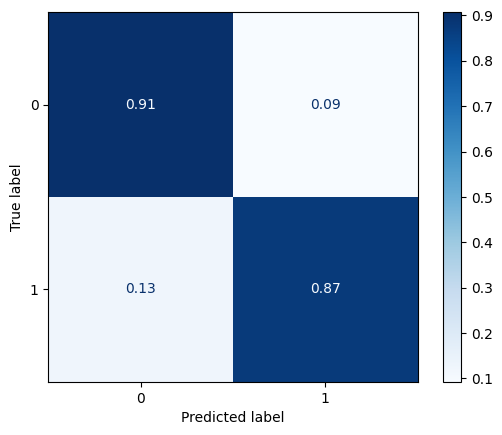

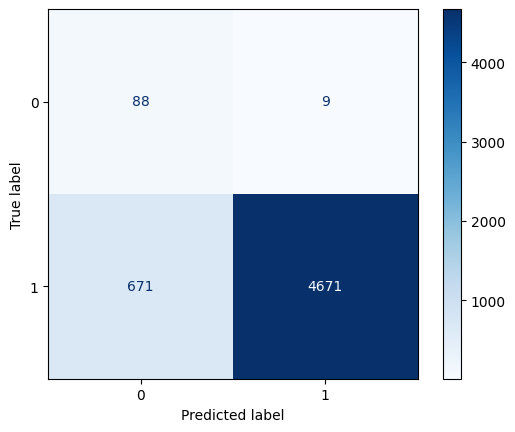

              precision    recall  f1-score   support

 0: standing   0.115942  0.907216  0.205607        97
  1: walking   0.998077  0.874392  0.932149      5342

    accuracy                       0.874977      5439
   macro avg   0.557009  0.890804  0.568878      5439
weighted avg   0.982345  0.874977  0.919192      5439

Balancierte Genauigkeit: 0.884239
Präzision: 		 0.115942
Sensitivität: 		 0.907216
Spezifität: 		 0.998077
NPR: 			 0.998077
F-Maß: 			 0.205607

Maximale Baumtiefe: 	 1
Anzahl Schätzer: 	 541
Anzahl der Knoten: 	 1623


In [54]:
# Konfusionsmatrizen plotten

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest, ytest, cmap='Blues', normalize='true', values_format='.2f')
plt.title('')
plt.show()

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest, ytest, cmap="Blues" ,values_format='d')
plt.show()

print(skm.classification_report(ytest,yhat_final, labels=[0,1], target_names=['0: standing','1: walking'], digits=6))

# Kennzahlen ermitteln

tp, fp, tn, fn = 88, 671, 4671, 9
bAcc = skm.balanced_accuracy_score(ytest, yhat)
sens = tp/(tp + fn)
spec = tn/(tn + fn)
prec = tp/(tp + fp)
npv = tn/(tn + fn)
fscore = 2 * ((prec * sens) / (prec + sens))

print(f"Balancierte Genauigkeit: {'%.6f' % bAcc}")
print(f"Präzision: \t\t {'%.6f' % prec}")
print(f"Sensitivität: \t\t {'%.6f' % sens}")
print(f"Spezifität: \t\t {'%.6f' % spec}")
print(f"NPR: \t\t\t {'%.6f' % npv}")
print(f"F-Maß: \t\t\t {'%.6f' % fscore}\n")

print(f"Maximale Baumtiefe: \t {best_depth}")
print(f"Anzahl Schätzer: \t {bestIterList[best_depth-1]}")
print(f"Anzahl der Knoten: \t 1623")


## 2.2 Wrapper-Methode: Rekursive Feature Eliminierung (CV)

### 2.2.1 "Optimale" Auswahl an Features ermitteln

Optimal number of features: 2


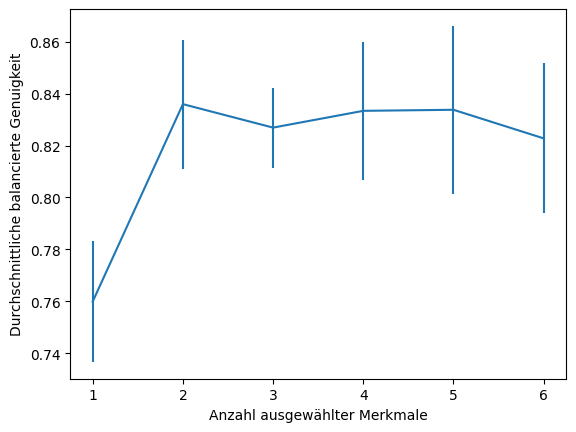

In [55]:
min_features_to_select = 1  # Minimum number of features to consider

clf = XGBClassifier(
    tree_method = "exact",
    scale_pos_weight = classratio
)
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="balanced_accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=-1,
)
rfecv.fit(xtrain_all, ytrain)

print(f"Optimal number of features: {rfecv.n_features_}")

cv_results = pd.DataFrame(rfecv.cv_results_)
plt.figure()
plt.xlabel("Anzahl ausgewählter Merkmale")
plt.ylabel("Durchschnittliche balancierte Genuigkeit")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.show()

### 2.2.2 Teilmengen erzeugen

In [56]:
xtrain_filtered_list = [col for col, keep in zip(xtrain_all.columns, rfecv.support_) if keep]

xtrain_rfecv = xtrain_all[xtrain_filtered_list]
xval_rfecv = xval_all[xtrain_filtered_list]
xtest_rfecv = xtest_all[xtrain_filtered_list]

xtrain_rfecv.to_csv("datasets/agmp/feature_selection/agmp_xtrain_rfecv.csv", index=False, sep=",")
xval_rfecv.to_csv("datasets/agmp/feature_selection/agmp_xval_rfecv.csv",index=False, sep=",")
xtest_rfecv.to_csv("datasets/agmp/feature_selection/agmp_xtest_rfecv.csv",index=False, sep=",")

ev_val = [(xval_rfecv,yval)]
ev_all = [(xtrain_rfecv,ytrain),(xval_rfecv,yval),(xtest_rfecv,ytest)]

### 2.2.3 Parameter für n_estimators und max_depth suchen

In [57]:
bestIterList_rfecv = []
accListBalanced_rfecv = []
jsonSizeList_rfecv = []

maximum = 30

for i in range(1, maximum+1):

    clf_temp = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        scale_pos_weight = classratio,
        n_estimators = 100000,
        early_stopping_rounds = 10,
        max_depth = i
    )
    clf_temp.fit(
        xtrain_rfecv, ytrain,
        eval_set = ev_val,
        verbose = 0
    )
    
    bestIter_temp = clf_temp.best_iteration

    clf_temp_bestIter = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        scale_pos_weight = classratio,
        n_estimators = bestIter_temp,
        max_depth = i
    )
    clf_temp_bestIter.fit(xtrain_rfecv, ytrain)

    yhat_temp_bestIter = clf_temp_bestIter.predict(xtest_rfecv)

    bAcc_temp = skm.balanced_accuracy_score(ytest, yhat_temp_bestIter)
    
    clf_temp_bestIter.save_model("clf_temp.json")

    jsonSizeList_rfecv.append(os.path.getsize('clf_temp.json'))
    accListBalanced_rfecv.append(bAcc_temp)
    bestIterList_rfecv.append(bestIter_temp)

    os.remove('clf_temp.json')

In [58]:
jsonSizeList_KB_rfecv = [x/1024 for x in jsonSizeList_rfecv]
bestIterationValues_rfecv = getBestDepth(accListBalanced_rfecv, jsonSizeList_KB_rfecv)
best_depth_rfecv = bestIterationValues_rfecv.index[0]+1

### 2.2.4 Graphen für Suche nach Params plotten

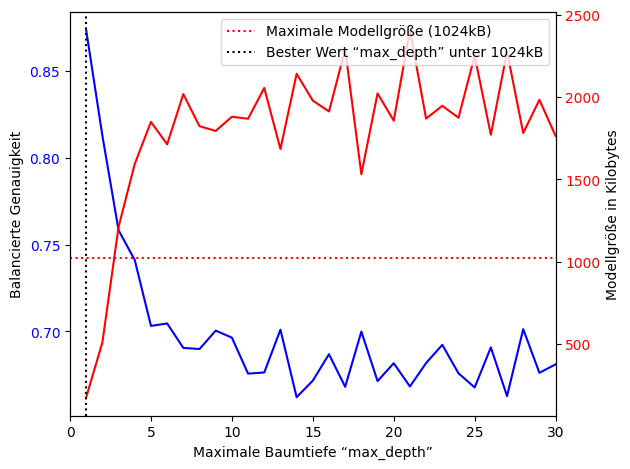

In [59]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Balancierte Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(1,31),accListBalanced_rfecv[:30],color="blue")
ax.set_xlim(0,30)

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
# twin.set_ylim(200,1450)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(1,31),jsonSizeList_KB_rfecv[:30],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth_rfecv, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

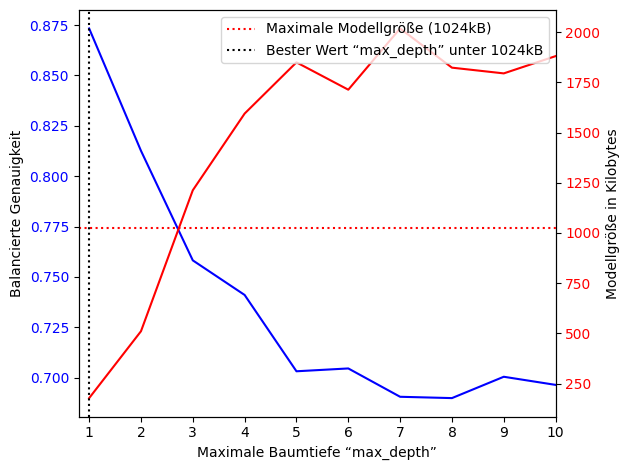

In [60]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Balancierte Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(1,11),accListBalanced_rfecv[:10],color="blue")
ax.set_xticks(range(1,11))
ax.set_xlim((0.8),10)

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
# twin.set_ylim(200,1150)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(1,11),jsonSizeList_KB_rfecv[:10],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth_rfecv, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

### 2.2.5 Finales Modell erzeugen

In [61]:
clf_final = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    scale_pos_weight = classratio, # Increase weight of minority class 
    n_estimators = bestIterList_rfecv[best_depth_rfecv-1],
    max_depth = best_depth_rfecv
)
clf_final.fit(
    xtrain_rfecv,ytrain,
    eval_set = ev_all,
    verbose = 0
)

yhat_final_rfecv = clf_final.predict(xtest_rfecv)

clf_final.save_model("model-exports/aktuelle-exports/fs_rfecv_agmp.json")
clf_final.get_booster().dump_model("model-exports/aktuelle-exports/fs_rfecv_agmp_dump.json")

### 2.2.6 Evaluierung

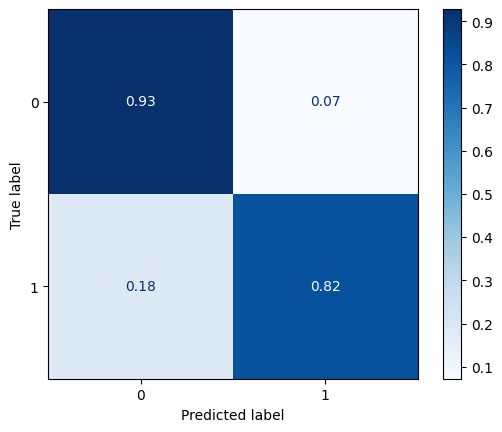

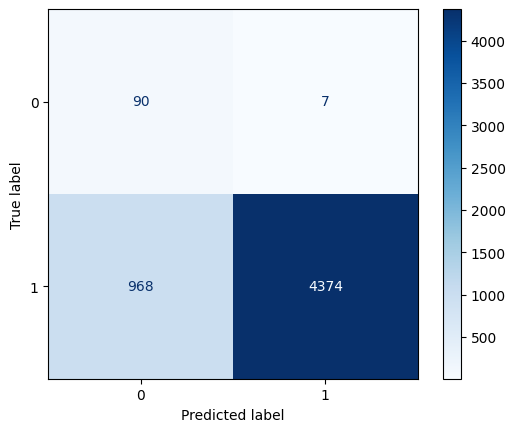

              precision    recall  f1-score   support

 0: standing   0.085066  0.927835  0.155844        97
  1: walking   0.998402  0.818794  0.899722      5342

    accuracy                       0.820739      5439
   macro avg   0.541734  0.873315  0.527783      5439
weighted avg   0.982114  0.820739  0.886456      5439

Balancierte Genauigkeit: 0.873315
Präzision: 		 0.085066
Sensitivität: 		 0.927835
Spezifität: 		 0.998402
NPR: 			 0.998402
F-Maß: 			 0.155844

Maximale Baumtiefe: 	 1
Anzahl Schätzer: 	 334
Anzahl der Knoten: 	 1623


In [62]:
# Konfusionsmatrizen plotten

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest_rfecv, ytest, cmap='Blues', normalize='true', values_format='.2f')
plt.title('')
plt.show()

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest_rfecv, ytest, cmap="Blues" ,values_format='d')
plt.show()

print(skm.classification_report(ytest,yhat_final_rfecv, labels=[0,1], target_names=['0: standing','1: walking'], digits=6))

# Kennzahlen ermitteln

tp, fp, tn, fn = 90, 968, 4374, 7
bAcc = skm.balanced_accuracy_score(ytest, yhat_final_rfecv)
sens = tp/(tp + fn)
spec = tn/(tn + fn)
prec = tp/(tp + fp)
npv = tn/(tn + fn)
fscore = 2 * ((prec * sens) / (prec + sens))

print(f"Balancierte Genauigkeit: {'%.6f' % bAcc}")
print(f"Präzision: \t\t {'%.6f' % prec}")
print(f"Sensitivität: \t\t {'%.6f' % sens}")
print(f"Spezifität: \t\t {'%.6f' % spec}")
print(f"NPR: \t\t\t {'%.6f' % npv}")
print(f"F-Maß: \t\t\t {'%.6f' % fscore}\n")

print(f"Maximale Baumtiefe: \t {best_depth_rfecv}")
print(f"Anzahl Schätzer: \t {bestIterList_rfecv[best_depth_rfecv-1]}")
print(f"Anzahl der Knoten: \t 1623")
